<a href="https://colab.research.google.com/github/feliper1/Ciencia_de_dados/blob/main/5_Imputacao_Faltantes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import requests
import os
from urllib.parse import urlparse
import re

URLS = [
    "https://mauabr-my.sharepoint.com/:x:/g/personal/23_01260-9_maua_br/IQBIcLW75T6cQZcg6il81WxeAaxFD5MfA_pzx4ZI2mdok7Y?e=fhPs30&download=1",
    "https://mauabr-my.sharepoint.com/:x:/g/personal/23_01260-9_maua_br/IQAOh-pBAMFpRqIgSuS7nu12AS5yUGfw0n7rBqNpDe4uVsM?e=x518j2&download=1",
    "https://mauabr-my.sharepoint.com/:x:/g/personal/23_01260-9_maua_br/IQCgb-vOBCCnQLfjN8y9BgweAXrIOYzwbdgrduu9BlPaRVU?e=LHqKLo&download=1"
]

PASTA_DESTINO = "/content"

os.makedirs(PASTA_DESTINO, exist_ok=True)


def baixar_arquivo(url, numero):

    print("\n" + "=" * 70)
    print(f"ARQUIVO {numero}")
    print("=" * 70)

    try:

        with requests.get(
            url,
            stream=True,
            allow_redirects=True,
            timeout=60
        ) as response:

            response.raise_for_status()

            print("Status:", response.status_code)
            print("Tipo:", response.headers.get("Content-Type"))

            nome_arquivo = None

            content_disposition = response.headers.get(
                "Content-Disposition"
            )

            if content_disposition:

                match = re.search(
                    r'filename="?([^"]+)"?',
                    content_disposition
                )

                if match:
                    nome_arquivo = match.group(1)

            if not nome_arquivo:

                caminho_url = urlparse(
                    response.url
                ).path

                nome_arquivo = os.path.basename(
                    caminho_url
                )

            if not nome_arquivo or "." not in nome_arquivo:
                nome_arquivo = f"arquivo_{numero}"

            nome_arquivo = os.path.basename(
                nome_arquivo
            )

            caminho_arquivo = os.path.join(
                PASTA_DESTINO,
                nome_arquivo
            )

            total = int(
                response.headers.get(
                    "Content-Length",
                    0
                )
            )

            downloaded = 0

            with open(
                caminho_arquivo,
                "wb"
            ) as f:

                for chunk in response.iter_content(
                    chunk_size=1024 * 1024
                ):

                    if chunk:

                        f.write(chunk)
                        downloaded += len(chunk)

                        if total > 0:

                            porcentagem = (
                                downloaded / total
                            ) * 100

                            print(
                                f"\rDownload: {porcentagem:.1f}%",
                                end=""
                            )

            tamanho_mb = (
                os.path.getsize(caminho_arquivo)
                / (1024 ** 2)
            )

            print("\n✓ Download concluído!")
            print(f"Arquivo: {nome_arquivo}")
            print(f"Tamanho: {tamanho_mb:.2f} MB")
            print(f"Local: {caminho_arquivo}")

            return caminho_arquivo

    except Exception as erro:

        print("\n✗ Erro ao baixar o arquivo:")
        print(erro)

        return None


print("\n" + "=" * 70)
print("DOWNLOAD DOS ARQUIVOS")
print("=" * 70)

arquivos_baixados = []

for numero, url in enumerate(URLS, start=1):

    caminho = baixar_arquivo(
        url,
        numero
    )

    if caminho:
        arquivos_baixados.append(caminho)


print("\n" + "=" * 70)
print("RESUMO")
print("=" * 70)

print(f"\nArquivos solicitados: {len(URLS)}")
print(f"Arquivos baixados: {len(arquivos_baixados)}")
print(f"Pasta: {PASTA_DESTINO}")

if arquivos_baixados:

    print("\nArquivos disponíveis:")

    for arquivo in arquivos_baixados:
        print(f"  ✓ {arquivo}")



DOWNLOAD DOS ARQUIVOS

ARQUIVO 1
Status: 200
Tipo: application/octet-stream
Download: 100.0%
✓ Download concluído!
Arquivo: jogos.csv
Tamanho: 0.01 MB
Local: /content/jogos.csv

ARQUIVO 2
Status: 200
Tipo: application/octet-stream
Download: 100.0%
✓ Download concluído!
Arquivo: cervejas.csv
Tamanho: 0.02 MB
Local: /content/cervejas.csv

ARQUIVO 3
Status: 200
Tipo: application/octet-stream
Download: 100.0%
✓ Download concluído!
Arquivo: funcionarios.csv
Tamanho: 0.01 MB
Local: /content/funcionarios.csv

RESUMO

Arquivos solicitados: 3
Arquivos baixados: 3
Pasta: /content

Arquivos disponíveis:
  ✓ /content/jogos.csv
  ✓ /content/cervejas.csv
  ✓ /content/funcionarios.csv


# Aula 5 - Imputação de Valores Faltantes

**Disciplina:** Ciência de Dados (CIC405)
**Professor:** Evandro Catelani Ferraz

Nesta aula vamos ver duas famílias de técnicas para lidar com valores faltantes em uma base de dados:

1. **Imputação simples (estatística):** substituir valores faltantes por uma estatística fixa (média, mediana, moda). É rápida e fácil, mas ignora as relações entre as variáveis.
2. **Imputação por modelo preditivo:** treinar um modelo (regressão linear, KNN ou árvore) para *prever* o valor faltante a partir das outras colunas. Mais preciso quando existem relações fortes entre as variáveis.

O objetivo é entender **quando usar cada abordagem** e como aplicá-las na prática.

> **Antes de começar:** faça o upload dos arquivos `funcionarios.csv` e `cervejas.csv` no mesmo diretório deste notebook.

## Por que precisamos imputar?

A maioria dos algoritmos de aprendizado de máquina não trabalha com valores faltantes. Se houver um NaN na base, o `.fit()` do scikit-learn vai lançar erro. Temos essencialmente duas saídas:

- **Remover** as linhas (ou colunas) com faltantes: simples, mas perde dados. Só faz sentido quando há **poucos** faltantes (menos de 5%) e a base é grande o suficiente.
- **Imputar** os valores faltantes: preencher os NaN com algum valor razoável, preservando a informação das outras colunas dessa linha.

A escolha entre essas abordagens depende de quantos faltantes existem e do impacto que a remoção teria no tamanho da base.

---

## Parte 1 - Imputação Simples (Estatística)

A imputação simples substitui todos os NaN de uma coluna por uma **estatística única** calculada nos valores presentes daquela coluna. As três estratégias mais comuns são:

- **Média:** para variáveis numéricas com distribuição aproximadamente simétrica.
- **Mediana:** para variáveis numéricas com distribuição assimétrica ou com outliers.
- **Moda:** para variáveis categóricas. É a única opção que faz sentido, já que não existe "média" de categoria.

Vamos aplicar as três em uma base de RH com dados de 200 funcionários.

### 1.1 Explorando a base de funcionários

In [3]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer

df = pd.read_csv('funcionarios.csv')

print('Shape:', df.shape)
print('\nTipos:')
print(df.dtypes)
print('\nValores faltantes por coluna:')
print(df.isnull().sum())
df.head()

Shape: (200, 6)

Tipos:
ID_Funcionario         int64
IdadeAnos            float64
SalarioMensal        float64
Departamento          object
Cargo                 object
TempoEmpresa_Anos    float64
dtype: object

Valores faltantes por coluna:
ID_Funcionario        0
IdadeAnos            20
SalarioMensal        20
Departamento         20
Cargo                 0
TempoEmpresa_Anos     0
dtype: int64


,ID_Funcionario,IdadeAnos,SalarioMensal,Departamento,Cargo,TempoEmpresa_Anos
0,1,42.0,3394.12,Financeiro,Assistente,6.5
1,2,43.0,16023.87,TI,Gerente,7.8
2,3,41.0,9583.77,Marketing,Coordenador,7.8
3,4,24.0,8181.34,RH,Analista,1.1
4,5,18.0,5980.73,Vendas,Analista,0.0


Três colunas têm faltantes: `IdadeAnos`, `SalarioMensal` e `Departamento`. Vamos aplicar a estratégia adequada para cada uma.

### 1.2 Imputação por média: `IdadeAnos`

A idade dos funcionários tende a ter distribuição aproximadamente **simétrica** (a maioria fica em torno do valor médio, sem muitos valores extremos puxando a distribuição para um lado). Nesse caso, a **média** é uma boa escolha.

In [4]:
# Antes: quantos NaN existem
print(f'NaN antes: {df["IdadeAnos"].isnull().sum()}')
print(f'Média calculada dos valores presentes: {df["IdadeAnos"].mean():.2f}')

# Aplicando SimpleImputer
imp_media = SimpleImputer(strategy='mean')
df['IdadeAnos'] = imp_media.fit_transform(df[['IdadeAnos']])

print(f'\nNaN depois: {df["IdadeAnos"].isnull().sum()}')
print(f'Valor usado na imputação: {imp_media.statistics_[0]:.2f}')

NaN antes: 20
Média calculada dos valores presentes: 37.52

NaN depois: 0
Valor usado na imputação: 37.52


### 1.3 Imputação por mediana: `SalarioMensal`

Salários costumam ter distribuição **assimétrica**. A maioria dos funcionários ganha valores intermediários, mas alguns poucos ganham valores muito acima do típico (cargos altos, comissionados), que ficam bastante distantes do restante. Nessa situação a média fica "puxada" para cima por esses valores discrepantes, e a **mediana** representa melhor o salário típico.

Vamos primeiro visualizar a distribuição para confirmar:

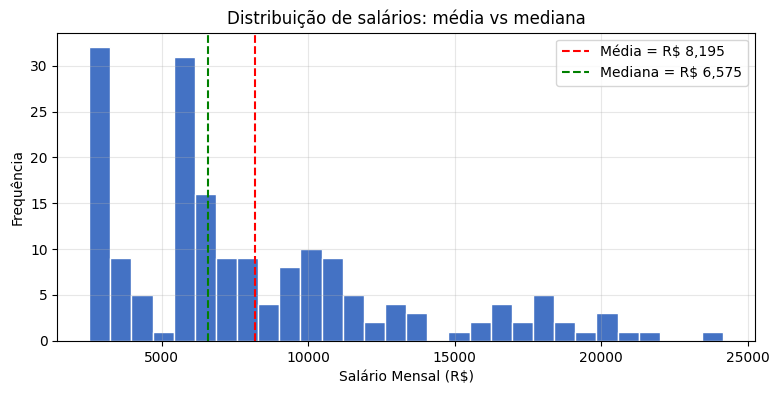

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 4))
df['SalarioMensal'].dropna().hist(bins=30, color='#4472C4', edgecolor='white')
plt.axvline(df['SalarioMensal'].mean(), color='red', linestyle='--', label=f"Média = R$ {df['SalarioMensal'].mean():,.0f}")
plt.axvline(df['SalarioMensal'].median(), color='green', linestyle='--', label=f"Mediana = R$ {df['SalarioMensal'].median():,.0f}")
plt.xlabel('Salário Mensal (R$)')
plt.ylabel('Frequência')
plt.title('Distribuição de salários: média vs mediana')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Repare que a média está bem à direita da mediana, "puxada" pelos salários mais altos. A mediana representa melhor o "salário típico". Vamos aplicar:

In [6]:
imp_mediana = SimpleImputer(strategy='median')
df['SalarioMensal'] = imp_mediana.fit_transform(df[['SalarioMensal']])

print(f'NaN restantes em SalarioMensal: {df["SalarioMensal"].isnull().sum()}')
print(f'Valor usado na imputação (mediana): R$ {imp_mediana.statistics_[0]:,.2f}')

NaN restantes em SalarioMensal: 0
Valor usado na imputação (mediana): R$ 6,575.00


### 1.4 Imputação por moda: `Departamento`

Não faz sentido calcular média ou mediana de uma variável categórica. "Média entre TI e RH" não existe. A única estatística aplicável é a **moda**, ou seja, o valor mais frequente.

In [7]:
print('Frequência de cada departamento (antes da imputação):')
print(df['Departamento'].value_counts(dropna=False))

imp_moda = SimpleImputer(strategy='most_frequent')
df['Departamento'] = imp_moda.fit_transform(df[['Departamento']]).ravel()

print(f'\nValor usado na imputação (moda): {imp_moda.statistics_[0]}')
print(f'NaN restantes: {df["Departamento"].isnull().sum()}')

Frequência de cada departamento (antes da imputação):
Departamento
Vendas        63
TI            46
Financeiro    32
Marketing     21
NaN           20
RH            18
Name: count, dtype: int64

Valor usado na imputação (moda): Vendas
NaN restantes: 0


### 1.5 Vantagens e limitações da imputação simples

**Vantagens:**
- Rápida e simples de implementar.
- Determinística e fácil de explicar para *stakeholders* não-técnicos.
- Funciona bem quando há poucos faltantes (menos de 5%).

**Limitações:**
- **Ignora as relações entre variáveis.** Todos os funcionários com salário faltante recebem exatamente a mesma mediana, mesmo que uns sejam Estagiários e outros Gerentes.
- **Reduz a variância** dos dados. Quando muitos valores são substituídos pela mesma estatística, a variabilidade da variável diminui artificialmente.
- **Pode introduzir viés** se os valores faltantes não forem aleatórios. Por exemplo, se as pessoas com salário muito alto tendem a não responder a pesquisas salariais.

Para casos em que existem **relações fortes** entre a coluna com faltantes e outras colunas da base, vale considerar uma abordagem mais sofisticada: usar as outras colunas para *prever* o valor faltante. É o que veremos na Parte 2.

---

## Parte 2 - Imputação por Modelo Preditivo

A ideia central é simples. Se a coluna com faltantes tem relação com as outras colunas da base, podemos **treinar um modelo** que aprenda essa relação a partir das linhas completas e depois usar esse modelo para **prever** os valores faltantes.

**Setup:** vamos usar uma base de 500 cervejas artesanais, **completa** (sem faltantes). Para cada modelo, vamos plantar NaN de forma controlada em uma coluna e, depois de imputar, comparar os valores previstos com os originais para medir a qualidade da imputação. Isso é possível justamente porque temos o "gabarito".

### 2.0 Carregando e explorando a base de cervejas

A base contém características técnicas de 500 cervejas artesanais:

- `TeorAlcoolico`: percentual de álcool (ABV)
- `IBU`: unidades internacionais de amargor (quanto maior, mais amarga)
- `CorEBC`: cor na escala EBC (valores baixos = clara; altos = escura)
- `DensidadeOG`: densidade inicial antes da fermentação
- `EstiloCerveja`: estilo (Pilsen, IPA, Weiss, Stout ou APA)
- `Preco`: preço da garrafa de 500ml em reais

In [8]:
df_cerv = pd.read_csv('cervejas.csv')
print('Shape:', df_cerv.shape)
print('\nFaltantes:', df_cerv.isnull().sum().sum())
print('\nDistribuição de EstiloCerveja:')
print(df_cerv['EstiloCerveja'].value_counts())
df_cerv.head()

Shape: (500, 6)

Faltantes: 0

Distribuição de EstiloCerveja:
EstiloCerveja
Pilsen    122
IPA       113
APA       104
Weiss      85
Stout      76
Name: count, dtype: int64


,TeorAlcoolico,IBU,CorEBC,DensidadeOG,EstiloCerveja,Preco
0,5.05,17.9,15.9,1.051,Weiss,15.18
1,5.65,36.9,15.7,1.056,APA,22.16
2,5.81,34.5,71.2,1.082,Stout,27.05
3,4.09,21.0,13.0,1.047,Pilsen,13.42
4,5.62,67.3,14.9,1.068,IPA,28.51


### 2.1 Regressão Linear: imputando `Preco`

**Quando usar:** para imputar variáveis **numéricas** que têm **relação linear** com outras colunas. É o caso do preço da cerveja, que depende bastante do teor alcoólico, IBU, cor e estilo.

**Estratégia:**
1. Plantar NaN em 15% dos valores de `Preco` (guardando os originais para comparar).
2. Separar as linhas em duas partes: as **completas** (para treino) e as com **NaN** (para prever).
3. Treinar uma regressão linear nas linhas completas.
4. Usar o modelo para prever os valores faltantes.
5. Comparar as previsões com os valores originais.

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn import metrics

# Faz uma copia para nao afetar a base original
df_reg = df_cerv.copy()

# Guarda os valores originais para comparar depois
rng = np.random.default_rng(42)
idx_faltantes = rng.choice(df_reg.index, size=int(0.15 * len(df_reg)), replace=False)
valores_originais = df_reg.loc[idx_faltantes, 'Preco'].copy()

# Planta NaN
df_reg.loc[idx_faltantes, 'Preco'] = np.nan
print(f'NaN plantados em Preco: {df_reg["Preco"].isnull().sum()}')

NaN plantados em Preco: 75


In [10]:
# Precisamos converter EstiloCerveja (categorica) em numerica via one-hot
df_reg_encoded = pd.get_dummies(df_reg, columns=['EstiloCerveja'], drop_first=True, dtype=int)

# Separa linhas completas (para treino) e linhas com NaN (para prever)
completas = df_reg_encoded[df_reg_encoded['Preco'].notna()]
faltantes = df_reg_encoded[df_reg_encoded['Preco'].isna()]

X_train = completas.drop('Preco', axis=1)
y_train = completas['Preco']
X_faltantes = faltantes.drop('Preco', axis=1)

print(f'Linhas de treino: {len(completas)} | Linhas a imputar: {len(faltantes)}')

Linhas de treino: 425 | Linhas a imputar: 75


In [11]:
# Treinar a regressao linear
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# Prever os valores faltantes usando pd.Series para preservar o indice
# (essencial para alinhar corretamente com os valores originais depois)
y_pred_imputados = pd.Series(
    modelo.predict(X_faltantes),
    index=X_faltantes.index
)

# Preencher a coluna com os valores previstos
df_reg.loc[y_pred_imputados.index, 'Preco'] = y_pred_imputados
print(f'NaN restantes: {df_reg["Preco"].isnull().sum()}')

NaN restantes: 0


**Avaliando a qualidade da imputação:** como plantamos os NaN artificialmente, sabemos os valores reais e podemos comparar.

In [12]:
# Alinhar valores originais e imputados pelo mesmo indice
originais = valores_originais.sort_index()
imputados = y_pred_imputados.sort_index()

mae = metrics.mean_absolute_error(originais, imputados)
rmse = np.sqrt(metrics.mean_squared_error(originais, imputados))
media = originais.mean()

print(f'MAE:  R$ {mae:.2f}  ({100 * mae / media:.2f}% do valor médio)')
print(f'RMSE: R$ {rmse:.2f}  ({100 * rmse / media:.2f}% do valor médio)')

# Comparacao para os primeiros 5 casos
comparacao = pd.DataFrame({
    'Real': originais.iloc[:5].values,
    'Imputado': imputados.iloc[:5].values.round(2),
    'Erro': (imputados.iloc[:5].values - originais.iloc[:5].values).round(2)
})
print('\nComparação (primeiros 5 casos):')
print(comparacao.to_string(index=False))

MAE:  R$ 1.27  (5.48% do valor médio)
RMSE: R$ 1.55  (6.69% do valor médio)

Comparação (primeiros 5 casos):
 Real  Imputado  Erro
11.23     13.34  2.11
17.21     17.39  0.18
16.12     14.64 -1.48
15.12     13.08 -2.04
23.57     23.08 -0.49


Os valores imputados ficam próximos dos reais porque `Preco` tem forte relação linear com as outras colunas. **Compare este erro com o que seria obtido imputando pela mediana:** a regressão linear leva em conta as características de cada cerveja, enquanto a mediana daria o mesmo preço para uma Pilsen simples e uma Stout premium.

### 2.2 KNN Imputer: imputando `TeorAlcoolico`

**Quando usar:** para imputar variáveis **numéricas** sem necessariamente exigir relação linear. O KNN Imputer procura os `k` vizinhos mais parecidos (nas outras colunas) e imputa a média dos valores deles. É uma boa opção quando a relação entre as variáveis não é claramente linear.

**Vantagem prática:** o `KNNImputer` do scikit-learn faz tudo automaticamente. Encontra vizinhos, calcula médias e preenche. Não precisamos separar treino e predição manualmente.

In [13]:
from sklearn.impute import KNNImputer

# Faz uma copia limpa
df_knn = df_cerv.copy()

# Planta NaN em 15% dos valores de TeorAlcoolico
rng = np.random.default_rng(123)
idx_faltantes = rng.choice(df_knn.index, size=int(0.15 * len(df_knn)), replace=False)
valores_originais = df_knn.loc[idx_faltantes, 'TeorAlcoolico'].copy()
df_knn.loc[idx_faltantes, 'TeorAlcoolico'] = np.nan

print(f'NaN plantados em TeorAlcoolico: {df_knn["TeorAlcoolico"].isnull().sum()}')

NaN plantados em TeorAlcoolico: 75


In [14]:
from sklearn.preprocessing import StandardScaler

# KNNImputer so aceita colunas numericas, entao precisamos preparar
df_knn_encoded = pd.get_dummies(df_knn, columns=['EstiloCerveja'], drop_first=True, dtype=int)

# Normaliza todas as colunas com StandardScaler (media 0, desvio 1)
# Assim o KNN nao sofre com colunas de escalas muito diferentes
scaler = StandardScaler()
df_knn_scaled = pd.DataFrame(
    scaler.fit_transform(df_knn_encoded),
    columns=df_knn_encoded.columns,
    index=df_knn_encoded.index
)

# Aplicar KNNImputer com k=5 vizinhos nos dados JA normalizados
knn_imp = KNNImputer(n_neighbors=5)
df_knn_imp_scaled = pd.DataFrame(
    knn_imp.fit_transform(df_knn_scaled),
    columns=df_knn_scaled.columns,
    index=df_knn_scaled.index
)

# Desfazer a normalizacao para voltar aos valores originais em %ABV
df_knn_imputado = pd.DataFrame(
    scaler.inverse_transform(df_knn_imp_scaled),
    columns=df_knn_imp_scaled.columns,
    index=df_knn_imp_scaled.index
)

# Extrair os valores imputados na coluna TeorAlcoolico
imputados = df_knn_imputado.loc[idx_faltantes, 'TeorAlcoolico']
print(f'NaN restantes: {df_knn_imputado["TeorAlcoolico"].isnull().sum()}')

NaN restantes: 0


In [15]:
# Avaliar a qualidade
mae = metrics.mean_absolute_error(valores_originais, imputados)
rmse = np.sqrt(metrics.mean_squared_error(valores_originais, imputados))
media = valores_originais.mean()

print(f'MAE:  {mae:.3f} %ABV  ({100 * mae / media:.2f}% do valor médio)')
print(f'RMSE: {rmse:.3f} %ABV  ({100 * rmse / media:.2f}% do valor médio)')

comparacao = pd.DataFrame({
    'Real': valores_originais.iloc[:5].values.round(2),
    'Imputado': imputados.iloc[:5].values.round(2),
    'Erro': (imputados.iloc[:5].values - valores_originais.iloc[:5].values).round(2)
})
print('\nComparação (primeiros 5 casos):')
print(comparacao.to_string(index=False))

MAE:  0.378 %ABV  (6.89% do valor médio)
RMSE: 0.527 %ABV  (9.60% do valor médio)

Comparação (primeiros 5 casos):
 Real  Imputado  Erro
 5.18      5.17 -0.01
 6.92      6.63 -0.29
 4.04      4.90  0.86
 6.91      6.67 -0.24
 5.25      5.26  0.01


#### Um cuidado importante: normalização das variáveis

O KNN Imputer usa **distância euclidiana** por padrão para encontrar os vizinhos mais próximos. A fórmula da distância entre dois pontos `p` e `q` (com várias variáveis preditivas) é:

$$d(p, q) = \sqrt{(p_1 - q_1)^2 + (p_2 - q_2)^2 + \dots + (p_n - q_n)^2}$$

O problema é que **essa fórmula não considera a escala das variáveis**. Se uma coluna tem valores na casa dos milhares (como salário: 3.000, 5.000, 12.000) e outra tem valores na casa das dezenas (como idade: 25, 30, 45), a coluna com valores maiores vai **dominar** a distância. A distância entre dois pontos vai acabar sendo decidida praticamente só pela diferença de salário, e a diferença de idade é ignorada na prática.

**A solução é a normalização** (também chamada de *padronização* ou *scaling*). O processo consiste em transformar as variáveis para que todas fiquem na mesma escala **antes** de calcular distâncias. A técnica mais comum é o **StandardScaler**, que transforma cada variável para ter:

- **Média zero:** subtrai a média original de todos os valores da coluna
- **Desvio padrão igual a um:** divide pelo desvio padrão original

A fórmula é: $z = (x - \mu) / \sigma$, onde $\mu$ é a média e $\sigma$ é o desvio padrão da coluna original.

Depois dessa transformação, todas as variáveis "falam a mesma língua" numérica. Uma diferença de 1 unidade em qualquer variável passa a representar 1 desvio padrão daquela variável original, o que é uma medida comparável entre colunas de escalas diferentes.

**Regra prática:** sempre que for usar KNN (para classificação, regressão ou imputação), aplique `StandardScaler` **antes**. E lembre da mesma regra do split: aprender a média e o desvio padrão apenas no treino (`fit_transform`) e aplicar os mesmos valores no teste (`transform`), para evitar *data leakage*.

### 2.3 Árvore de Decisão: imputando `EstiloCerveja`

**Quando usar:** para imputar variáveis **categóricas** (ou numéricas com padrões não-lineares). Nesse caso usamos uma árvore de **classificação**, pois estamos prevendo uma categoria (Pilsen, IPA, Weiss, Stout ou APA).

Como a variável a imputar é categórica, a métrica de avaliação muda. Usamos **acurácia** (percentual de imputações corretas) em vez de MAE/RMSE.

In [16]:
from sklearn.tree import DecisionTreeClassifier

# Faz uma copia limpa
df_arv = df_cerv.copy()

# Planta NaN em 15% dos valores de EstiloCerveja
rng = np.random.default_rng(456)
idx_faltantes = rng.choice(df_arv.index, size=int(0.15 * len(df_arv)), replace=False)
valores_originais = df_arv.loc[idx_faltantes, 'EstiloCerveja'].copy()
df_arv.loc[idx_faltantes, 'EstiloCerveja'] = np.nan

print(f'NaN plantados em EstiloCerveja: {df_arv["EstiloCerveja"].isnull().sum()}')

NaN plantados em EstiloCerveja: 75


In [17]:
# Separa linhas completas (treino) e com NaN (para imputar)
completas = df_arv[df_arv['EstiloCerveja'].notna()]
faltantes = df_arv[df_arv['EstiloCerveja'].isna()]

X_train = completas.drop('EstiloCerveja', axis=1)
y_train = completas['EstiloCerveja']
X_faltantes = faltantes.drop('EstiloCerveja', axis=1)

# Treina a arvore de classificacao
arvore = DecisionTreeClassifier(max_depth=5, random_state=0)
arvore.fit(X_train, y_train)

# Preve as categorias faltantes usando Series indexada para alinhamento correto
categorias_imputadas = pd.Series(
    arvore.predict(X_faltantes),
    index=X_faltantes.index
)

# Preenche
df_arv.loc[categorias_imputadas.index, 'EstiloCerveja'] = categorias_imputadas
print(f'NaN restantes: {df_arv["EstiloCerveja"].isnull().sum()}')

NaN restantes: 0


In [18]:
# Alinhar valores originais e imputados pelo mesmo indice
originais = valores_originais.sort_index()
imputados = categorias_imputadas.sort_index()

# Avaliar com acuracia
acuracia = (originais.values == imputados.values).mean()
print(f'Acurácia da imputação: {100 * acuracia:.1f}%')

# Matriz de confusao
from sklearn.metrics import confusion_matrix
cats = ['Pilsen', 'IPA', 'Weiss', 'Stout', 'APA']
cm = confusion_matrix(originais, imputados, labels=cats)
print('\nMatriz de confusão (linhas = real, colunas = imputado):')
print(pd.DataFrame(cm, index=cats, columns=cats).to_string())

# Comparacao para os primeiros 8 casos
comparacao = pd.DataFrame({
    'Real': originais.iloc[:8].values,
    'Imputado': imputados.iloc[:8].values,
    'Acertou': originais.iloc[:8].values == imputados.iloc[:8].values
})
print('\nComparação (primeiros 8 casos):')
print(comparacao.to_string(index=False))

Acurácia da imputação: 86.7%

Matriz de confusão (linhas = real, colunas = imputado):
        Pilsen  IPA  Weiss  Stout  APA
Pilsen      11    0      5      0    0
IPA          0   20      0      0    3
Weiss        2    0      9      0    0
Stout        0    0      0      9    0
APA          0    0      0      0   16

Comparação (primeiros 8 casos):
  Real Imputado  Acertou
   IPA      IPA     True
   APA      APA     True
Pilsen    Weiss    False
   IPA      IPA     True
 Weiss    Weiss     True
   IPA      IPA     True
   APA      APA     True
 Weiss    Weiss     True


A matriz de confusão mostra onde a árvore acerta e onde erra. É natural haver alguma confusão entre estilos próximos (por exemplo, Pilsen e Weiss são ambos claros com baixo amargor), enquanto estilos bem distintos (como Pilsen e Stout) tendem a ser bem diferenciados.

---

## Comparação: quando usar cada abordagem

| Situação | Estratégia recomendada |
|---|---|
| Poucos faltantes (< 5%) em variável numérica simétrica | Imputação por **média** |
| Poucos faltantes em variável numérica assimétrica ou com outliers | Imputação por **mediana** |
| Poucos faltantes em variável categórica | Imputação por **moda** |
| Variável numérica com relação **linear** com outras colunas | **Regressão linear** |
| Variável numérica com relação não-linear, ou muitas variáveis relacionadas | **KNN Imputer**; **Árvore de decisão** (regressão) |
| Variável **categórica** com múltiplas preditoras | **Árvore de decisão** (classificação) |

---

# Exercícios

Os exercícios usam a base `jogos.csv`, com 300 jogos de videogame. A base já vem com valores faltantes plantados em algumas colunas. As colunas são:

- `ID_Jogo`: identificador único
- `Genero`: gênero (RPG, Ação, Estratégia, Esporte, Puzzle, Aventura) - **categórica**
- `AnoLancamento`: ano de lançamento
- `HorasParaCompletar`: horas médias para terminar o jogo
- `NotaMetacritic`: nota agregada (0 a 100)
- `Preco`: preço de lançamento em reais
- `JogadoresOnline`: número médio de jogadores online

Carregue a base com o código abaixo:

In [19]:
df_jogos = pd.read_csv('jogos.csv')
print('Shape:', df_jogos.shape)
print('\nFaltantes por coluna:')
print(df_jogos.isnull().sum())
df_jogos.head()

Shape: (300, 7)

Faltantes por coluna:
ID_Jogo                0
Genero                24
AnoLancamento          0
HorasParaCompletar     0
NotaMetacritic        30
Preco                 30
JogadoresOnline        0
dtype: int64


,ID_Jogo,Genero,AnoLancamento,HorasParaCompletar,NotaMetacritic,Preco,JogadoresOnline
0,1,Aventura,2009,31.0,70.0,223.89,2753
1,2,Acao,2000,22.3,93.0,199.82,2773
2,3,Puzzle,2022,6.4,59.0,107.37,154
3,4,Puzzle,2016,5.2,64.0,114.83,203
4,5,Aventura,2007,39.6,77.0,241.81,4118


## Exercício 1 - estratégia para variável categórica

Uma base de dados tem uma coluna chamada `Genero` do tipo categórica (com valores como "RPG", "Ação", "Esporte"). Alguns valores estão faltantes. **Qual estratégia de imputação simples é a mais adequada?** Justifique sua escolha.

**Alternativas:**

(a) Substituir pela **média** dos gêneros existentes.

(b) Substituir pela **mediana** dos gêneros existentes.

(c) Substituir pela **moda** (gênero mais frequente na base).

(d) Substituir por **zero** em todos os registros faltantes.

# Resposta:

A alternativa certa é a "c", porque como a coluna "Genero" não apreseneta valores numéricos não teria como fazer média e mediana. Além de que substituir por "0" nos valores faltantes não faria sentido porque não tem essa opção no banco de dados, seria melhor apagar essas linhas do que substituir por "0".


## Exercício 2 - por que fit apenas no treino?

Ao usar `SimpleImputer` do scikit-learn dentro de um *pipeline* de machine learning, devemos chamar `fit_transform()` apenas no conjunto de treino e usar somente `transform()` no conjunto de teste. **Por quê?**

**Alternativas:**

(a) Porque `fit_transform()` é mais lento e queremos economizar tempo ao processar o teste.

(b) Para evitar *data leakage*: se a mediana (ou moda) for calculada usando dados do teste, o modelo estará indiretamente "vendo" informação que deveria ser desconhecida na avaliação.

(c) Porque o método `transform()` sozinho é matematicamente mais preciso que `fit_transform()`.

(d) Não faz diferença; podemos usar `fit_transform()` em ambos os conjuntos sem problemas.

# Resposta:

A alternativa certa é a "b", porque se usar nos dois conjuntos é possivel que tenha vazamento nos dados, já que ele vai treinar com os dois conuntos de dados.

## Exercício 3: imputação simples completa

Aplique imputação simples em todas as colunas com faltantes da base `jogos.csv`, usando a estratégia adequada para cada tipo de variável.

**Tarefas:**

1. Identifique quais colunas têm faltantes e quantos.
2. Aplique `SimpleImputer` em cada coluna com faltantes:
   - Use **média** para colunas numéricas com distribuição simétrica.
   - Use **mediana** para colunas numéricas com distribuição assimétrica.
   - Use **moda** para colunas categóricas.
3. Confirme ao final que não há mais nenhum valor faltante na base.

**Dica:** você pode plotar histogramas para decidir entre média e mediana.

In [20]:
# Verificar os valores faltantes
print("Valores faltantes por coluna:")
print(df_jogos.isnull().sum())


Valores faltantes por coluna:
ID_Jogo                0
Genero                24
AnoLancamento          0
HorasParaCompletar     0
NotaMetacritic        30
Preco                 30
JogadoresOnline        0
dtype: int64


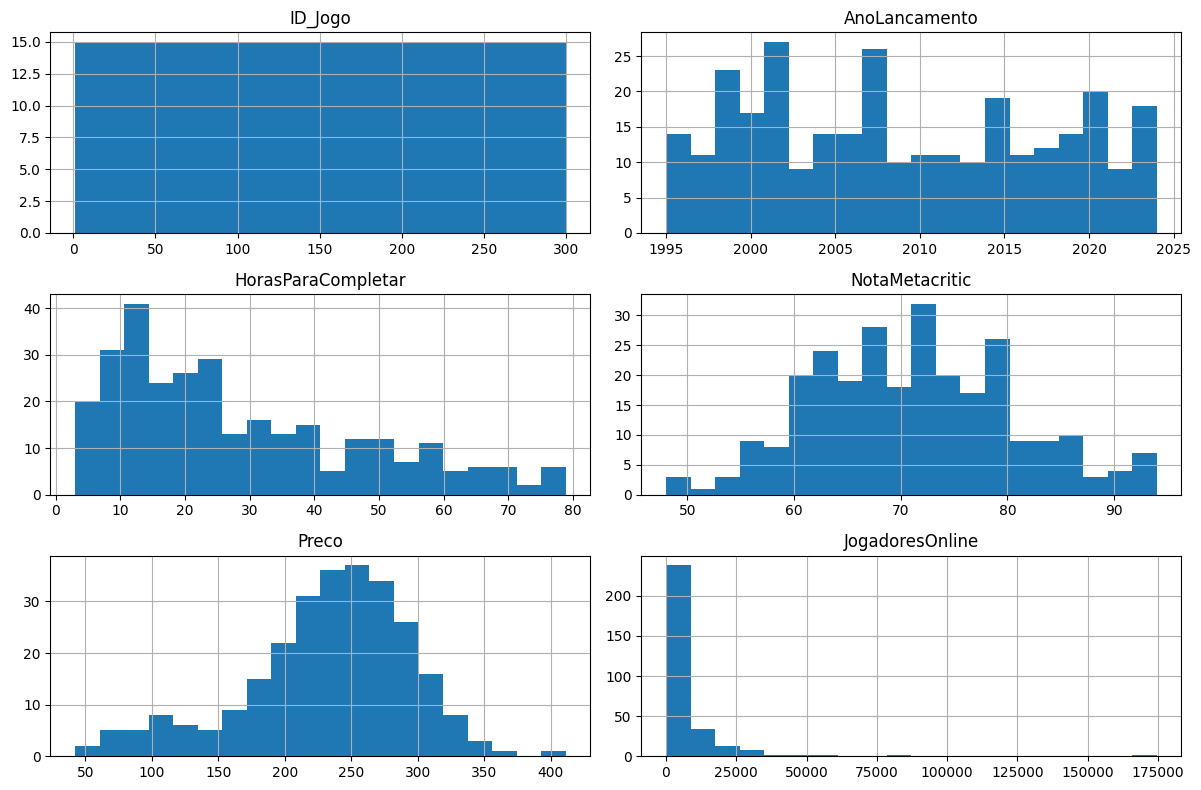

In [21]:
# Histogramas das colunas numéricas
df_jogos.hist(figsize=(12, 8), bins=20)
plt.tight_layout()
plt.show()


In [22]:
print(df_jogos[['NotaMetacritic', 'Preco']].describe())

print("\nMédias:")
print(df_jogos[['NotaMetacritic', 'Preco']].mean())

print("\nMedianas:")
print(df_jogos[['NotaMetacritic', 'Preco']].median())


       NotaMetacritic     Preco
count      270.000000  270.0000
mean        71.248148  232.5960
std          9.414529   62.7006
min         48.000000   42.3300
25%         64.250000  202.5975
50%         71.000000  241.6500
75%         77.750000  275.4075
max         94.000000  411.3300

Médias:
NotaMetacritic     71.248148
Preco             232.596000
dtype: float64

Medianas:
NotaMetacritic     71.00
Preco             241.65
dtype: float64


In [23]:
from sklearn.impute import SimpleImputer

df_imputado = df_jogos.copy()

imp_moda = SimpleImputer(strategy='most_frequent')

df_imputado[['Genero']] = imp_moda.fit_transform(
    df_imputado[['Genero']]
)

imp_media = SimpleImputer(strategy='mean')

df_imputado[['NotaMetacritic']] = imp_media.fit_transform(
    df_imputado[['NotaMetacritic']]
)

imp_mediana = SimpleImputer(strategy='median')

df_imputado[['Preco']] = imp_mediana.fit_transform(
    df_imputado[['Preco']]
)

print("Valor utilizado para Genero:", imp_moda.statistics_[0])
print("Valor utilizado para NotaMetacritic:", imp_media.statistics_[0])
print("Valor utilizado para Preco:", imp_mediana.statistics_[0])

print("\nValores faltantes após a imputação:")
print(df_imputado.isnull().sum())


Valor utilizado para Genero: Acao
Valor utilizado para NotaMetacritic: 71.24814814814815
Valor utilizado para Preco: 241.64999999999998

Valores faltantes após a imputação:
ID_Jogo               0
Genero                0
AnoLancamento         0
HorasParaCompletar    0
NotaMetacritic        0
Preco                 0
JogadoresOnline       0
dtype: int64


Primeiramente, foram identificadas as colunas que possuíam valores faltantes. A coluna Genero apresentou 24 valores faltantes, enquanto NotaMetacritic e Preco apresentaram 30 valores faltantes cada.

Para a coluna Genero, foi utilizada a moda, pois essa é uma variável categórica. Nesse caso, a moda corresponde ao gênero que aparece com maior frequência na base.

Para NotaMetacritic, foi utilizada a média, pois a média (71,25) e a mediana (71,00) apresentam valores muito próximos, indicando uma distribuição aproximadamente simétrica. Assim, a média é uma boa representação dos valores dessa variável.

Para Preco, foi utilizada a mediana, pois existe uma diferença maior entre a média R 232,60 e a mediana R$ 241,65, indicando uma possível assimetria na distribuição. A mediana é mais resistente a valores extremos e, portanto, é mais adequada nesse caso.

Após aplicar o SimpleImputer em todas as colunas que apresentavam valores faltantes, foi realizada uma nova verificação com isnull().sum(). O resultado apresentou zero valores faltantes em todas as colunas, confirmando que a imputação foi concluída corretamente.


## Exercício 4 - validando a qualidade da imputação

Vamos usar a técnica de plantar NaN artificialmente para **medir o erro** da imputação por mediana em uma coluna numérica.

**Tarefas:**

1. Carregue a base `jogos.csv` novamente e **remova todas as linhas que tenham qualquer valor faltante** (use `.dropna()`). Isso vai deixar uma base 100% completa para o experimento.
2. Faça uma cópia dessa base limpa.
3. Sorteie **20% dos índices** e plante NaN na coluna `HorasParaCompletar` desses índices. **Guarde os valores originais** antes de sobrescrever.
4. Aplique `SimpleImputer` com estratégia **mediana** para preencher os NaN.
5. Compare os valores imputados com os originais calculando **MAE e RMSE**.
6. Em uma célula markdown, comente: o erro obtido é aceitável? Por que a mediana pode ser insuficiente para essa coluna específica?

In [24]:
df_jogos = pd.read_csv('jogos.csv')

df_limpo = df_jogos.dropna().copy()

print("Tamanho da base original:", df_jogos.shape)
print("Tamanho da base após dropna():", df_limpo.shape)

print("\nValores faltantes após dropna():")
print(df_limpo.isnull().sum())

Tamanho da base original: (300, 7)
Tamanho da base após dropna(): (224, 7)

Valores faltantes após dropna():
ID_Jogo               0
Genero                0
AnoLancamento         0
HorasParaCompletar    0
NotaMetacritic        0
Preco                 0
JogadoresOnline       0
dtype: int64


In [25]:
df_teste = df_limpo.copy()

In [26]:
rng = np.random.default_rng(42)

quantidade_faltantes = int(0.20 * len(df_teste))

indices_faltantes = rng.choice(df_teste.index,size=quantidade_faltantes,replace=False)

valores_originais = df_teste.loc[indices_faltantes,'HorasParaCompletar'].copy()

df_teste.loc[indices_faltantes,'HorasParaCompletar'] = np.nan

print("\nQuantidade de NaN plantados:")
print(df_teste['HorasParaCompletar'].isnull().sum())


Quantidade de NaN plantados:
44


In [27]:
imputer = SimpleImputer(strategy='median')

df_teste[['HorasParaCompletar']] = imputer.fit_transform(df_teste[['HorasParaCompletar']])

print("\nNaN após a imputação:")
print(df_teste['HorasParaCompletar'].isnull().sum())

print("\nMediana utilizada:")
print(imputer.statistics_[0])


NaN após a imputação:
0

Mediana utilizada:
23.6


In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

valores_imputados = df_teste.loc[indices_faltantes,'HorasParaCompletar']

mae = mean_absolute_error(valores_originais,valores_imputados)

rmse = np.sqrt(mean_squared_error(valores_originais,valores_imputados))

print(f"MAE:  {mae:.2f} ")
print(f"RMSE: {rmse:.2f} ")

MAE:  12.59 
RMSE: 16.23 


# Resposta:

Na avaliação da qualidade da imputação, foi obtido um MAE de 12,59 horas e um RMSE de 16,23 horas. Esses valores indicam um erro considerável.

E a mediana pode ser insuficiente para essa coluna porque todos os valores faltantes recebem exatamente o mesmo valor, independentemente das características de cada jogo.

## Exercício 5 - comparando três estratégias de imputação

Neste exercício, você vai comparar **três estratégias diferentes** de imputação aplicadas à mesma coluna, para descobrir qual é a mais precisa.

**Tarefas:**

1. Carregue `jogos.csv` novamente e remova as linhas com qualquer faltante (base limpa).
2. Sorteie **20% dos índices** e plante NaN na coluna `Preco`. Guarde os valores originais.
3. Aplique as **três estratégias** de imputação abaixo (cada uma partindo de uma cópia fresca da base com NaN plantado):
   - **Estratégia A:** `SimpleImputer` com mediana
   - **Estratégia B:** Regressão linear (usando as demais colunas numéricas como preditoras e `Genero` via one-hot)
   - **Estratégia C:** `KNNImputer` com k=5. **Atenção:** aplique `StandardScaler` antes de passar os dados ao KNN Imputer (conforme discutido na Seção 2.2).
4. Para cada estratégia, calcule o **MAE** entre valores originais e imputados.
5. Monte uma tabela comparativa das três estratégias, ordenada da melhor para a pior.
6. Em uma célula markdown, discuta: qual estratégia teve o menor erro? Isso era esperado dado o que sabemos sobre a relação entre `Preco` e as outras colunas? A diferença justifica a complexidade adicional das estratégias B e C?

In [39]:
df_jogos = pd.read_csv('jogos.csv')

df_jogos = df_jogos.drop(columns='ID_Jogo')

df_limpo = df_jogos.dropna().copy()

print("Tamanho da base original:", df_jogos.shape)
print("Tamanho da base limpa:", df_limpo.shape)

print("\nValores faltantes:")
print(df_limpo.isnull().sum())

Tamanho da base original: (300, 6)
Tamanho da base limpa: (224, 6)

Valores faltantes:
Genero                0
AnoLancamento         0
HorasParaCompletar    0
NotaMetacritic        0
Preco                 0
JogadoresOnline       0
dtype: int64


In [40]:
df_jogos.head()

,Genero,AnoLancamento,HorasParaCompletar,NotaMetacritic,Preco,JogadoresOnline
0,Aventura,2009,31.0,70.0,223.89,2753
1,Acao,2000,22.3,93.0,199.82,2773
2,Puzzle,2022,6.4,59.0,107.37,154
3,Puzzle,2016,5.2,64.0,114.83,203
4,Aventura,2007,39.6,77.0,241.81,4118


In [41]:
rng = np.random.default_rng(42)

quantidade_faltantes = int(0.20 * len(df_limpo))

indices_faltantes = rng.choice(df_limpo.index,size=quantidade_faltantes,replace=False)

valores_originais = df_limpo.loc[indices_faltantes,'Preco'].copy()

df_com_nan = df_limpo.copy()

df_com_nan.loc[indices_faltantes,'Preco'] = np.nan

print("\nQuantidade de NaN plantados em Preco:")
print(df_com_nan['Preco'].isnull().sum())




Quantidade de NaN plantados em Preco:
44


In [42]:
#Estratégia A: SimpleImputer com mediana

df_mediana = df_com_nan.copy()
imputer_mediana = SimpleImputer(strategy='median')
df_mediana[['Preco']] = imputer_mediana.fit_transform(df_mediana[['Preco']])

valores_mediana = df_mediana.loc[indices_faltantes,'Preco']

mae_mediana = mean_absolute_error(valores_originais,valores_mediana)
print(f"Mediana utilizada: {imputer_mediana.statistics_[0]:.2f}")
print(f"MAE: {mae_mediana:.2f}")

Mediana utilizada: 240.63
MAE: 42.87


In [43]:
#Estratégia B: Regressão linear (usando as demais colunas numéricas como preditoras e Genero via one-hot)

df_regressao = df_com_nan.copy()

df_regressao_encoded = pd.get_dummies(df_regressao,columns=['Genero'],drop_first=True,dtype=int)

completos = df_regressao_encoded[df_regressao_encoded['Preco'].notna()]

faltantes = df_regressao_encoded[df_regressao_encoded['Preco'].isna()]

X_train = completos.drop('Preco', axis=1)
y_train = completos['Preco']

X_faltantes = faltantes.drop('Preco', axis=1)

modelo = LinearRegression()

modelo.fit(X_train,y_train)

previsoes_regressao = modelo.predict(X_faltantes)

valores_regressao = pd.Series(previsoes_regressao,index=X_faltantes.index)

mae_regressao = mean_absolute_error(valores_originais.sort_index(),valores_regressao.sort_index())

print(f"MAE: {mae_regressao:.2f}")

MAE: 22.09


In [44]:
#Estratégia C: KNNImputer com k=5. Atenção: aplique StandardScaler antes de passar os dados ao KNN Imputer

df_knn = df_com_nan.copy()

df_knn_encoded = pd.get_dummies(df_knn,columns=['Genero'],drop_first=True,dtype=int)

scaler = StandardScaler()

df_knn_scaled = pd.DataFrame(scaler.fit_transform(df_knn_encoded),columns=df_knn_encoded.columns,index=df_knn_encoded.index)

knn_imputer = KNNImputer(n_neighbors=5)

df_knn_imputado_scaled = pd.DataFrame(knn_imputer.fit_transform(df_knn_scaled),columns=df_knn_scaled.columns,index=df_knn_scaled.index)

df_knn_imputado = pd.DataFrame(scaler.inverse_transform(df_knn_imputado_scaled),columns=df_knn_imputado_scaled.columns,index=df_knn_imputado_scaled.index)

valores_knn = df_knn_imputado.loc[indices_faltantes,'Preco']

mae_knn = mean_absolute_error(valores_originais,valores_knn)

print(f"K: 5")
print(f"MAE: {mae_knn:.2f}")

K: 5
MAE: 26.92


In [47]:

df_comparacao = pd.DataFrame({'Estratégia':['Regressão Linear (Estratégia B)','KNNImputer k=5 (Estratégia C)','SimpleImputer Mediana (Estratégia A)',],'MAE (R$)': [mae_regressao, mae_knn, mae_mediana],}).sort_values(by='MAE (R$)')

print(df_comparacao.to_string(index=False))

                          Estratégia  MAE (R$)
     Regressão Linear (Estratégia B) 22.093430
       KNNImputer k=5 (Estratégia C) 26.918227
SimpleImputer Mediana (Estratégia A) 42.865909


# Resposta:

O resultado da regressão linear ser o menor já era esperado, porque ela utiliza as outras variáveis disponíveis para tentar estimar o preço do jogo. Mas o KNN podia ter se saído melhor, como é possível ver a diferença pequena entre eles, já que o KNN também usa as outras tabelas para tentar estimar o preço do jogo.

Neste caso, a maior complexidade da Regressão Linear parece ser justificada, pois houve uma redução significativa do erro em relação à mediana.

---

## Encerramento

Nesta aula vimos que a imputação é um passo importante da preparação de dados e que existem várias estratégias, cada uma com um caso de uso específico. Os modelos que já estudamos (regressão linear, KNN, árvores) mostraram-se úteis não só para prever a variável alvo do problema, mas também para preencher os buracos da própria base.